In [ ]:
%pip install ipympl matplotlib

# Solución a los notebooks Lab_05 y Lab_06

Como primer paso, solucionaremos la sección de "Vectorizando el gradiente descendente" paso a paso como se indica:



1. Generamos la ecuación $y=2.1*x_1 - 3.1 * x_2$

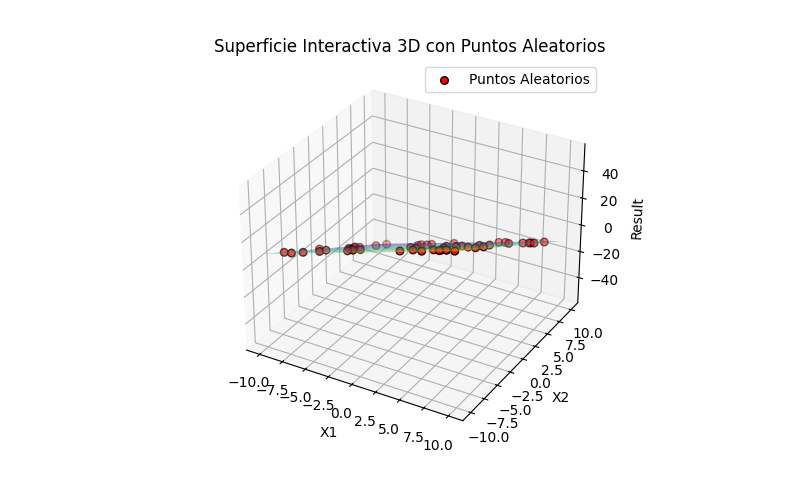

In [1]:
%matplotlib widget
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

# 1. Definimos la función a optimizar
def function_to_optimize(x1, x2):
    return 2.1 * x1 - 3.1 * x2

# 2. Creamos una malla (mesh) ordenada para dibujar el plano de fondo perfectamente
x1_range = np.linspace(-10, 10, 50)
x2_range = np.linspace(-10, 10, 50)
X1_mesh, X2_mesh = np.meshgrid(x1_range, x2_range)
Z_surface = function_to_optimize(X1_mesh, X2_mesh)

# 3. Generamos 50 puntos aleatorios distribuidos en el plano
x1_rand = np.random.uniform(-10, 10, 50)
x2_rand = np.random.uniform(-10, 10, 50)
z_rand = function_to_optimize(x1_rand, x2_rand)

# 4. Construimos la gráfica interactiva
fig = plt.figure(figsize=(8, 5))
ax = fig.add_subplot(111, projection='3d')

# Dibujamos el plano suave con un mapa de color
surface = ax.plot_surface(X1_mesh, X2_mesh, Z_surface, cmap='viridis', alpha=0.6)

# Dibujamos los puntos aleatorios encima en color rojo
ax.scatter(x1_rand, x2_rand, z_rand, color='red', s=30, edgecolor='black', label='Puntos Aleatorios')

# Configuraciones visuales
ax.set_xlabel('X1')
ax.set_ylabel('X2')
ax.set_zlabel('Result')
ax.set_title('Superficie Interactiva 3D con Puntos Aleatorios')
plt.legend()

plt.show()

Ya visualizamos los datos que vamos a usar para entrenar el modelo usando gradiente descendiente vectorial, ahora, creamos la matriz con los datos:

In [ ]:
training_data = np.array([np.zeros(50), x1_rand, x2_rand])
training_data = training_data.T
training_data[0]



array([ 0.        ,  5.81810602, -8.95165812])

In [37]:
training_data.dot(np.array([0,1,3]))

array([-21.03686832,  15.95246488, -31.27029417,  -2.75455179,
        28.12147663, -20.80353979,  18.28852492,  12.66558759,
       -17.53762484,  -1.33491346, -32.17936761,  34.1201519 ,
       -19.06868314,   0.74000862,  31.49937921, -14.88763893,
       -17.41130114, -13.10245363, -13.43569085,  14.64070039,
        28.47398753,   2.31263161,   8.66017494,   5.44508662,
        -3.14070838,  -1.4022916 , -15.1053544 ,  18.41098471,
        14.59050456, -25.96711672, -16.51555377,  27.16120821,
         8.41446556, -21.81694901,  -4.61384006, -35.56075694,
         6.42646995,  11.06378724, -19.41703023,   3.76371799,
       -14.95582419,  24.87518836, -14.92308273,  31.81351045,
        -1.56611569, -13.53863817,  24.72558986,  27.60598075,
        -7.50567696, -12.61872992])

In [42]:
training_data[:,1]

array([ 5.81810602, -2.96880954, -7.08529465,  4.30788676,  8.48502668,
        3.03488042, -8.40273234,  5.45897963,  7.15343298,  7.97711005,
       -9.4984709 ,  9.17885594, -7.27519322, -8.42591715,  4.78099057,
       -3.64961556, -3.99978877, -5.52809746,  5.50749471, -1.88233028,
        8.60336873,  6.27216077, -7.51227519,  4.07283202, -7.6212725 ,
       -7.21281043,  6.83570283, -2.10890024,  6.30446016, -6.27742836,
       -4.22628961,  9.26873028,  4.13614914, -3.57285691,  1.22578035,
       -7.48728379,  2.58235331, -2.29280452,  9.46146698,  7.86862674,
        7.4285053 ,  6.57529813,  3.27039073,  3.86104406, -0.22842013,
        7.19639707, -0.51817413,  7.80931762, -7.16682213, -9.99803081])

In [ ]:
#definimos la funcion de costo y la función de gradiente para luego aplicar el algoritmo de gradient_descendent
def cost_function(theta,X,y):
    m = len(y)
    predictions = X.dot(theta)
    cost = (1/m) * np.sum((predictions - y) ** 2)
    return cost

def grad_cost_function(theta,X,y):
    m = len(y)
    predictions = X.dot(theta)
    grad = (1/m) * X.T.dot(predictions - y)
    return grad

grad_cost_function(np.array([0,2.2,-3.1]), training_data, z_rand)

array([0.        , 3.98534001, 0.20441477])

In [ ]:
#aplicamos gradiendt descent para encontrar los valores de theta que minimizan la función de costo

def gradient_descent(X,y,theta,alpha,num_iters):
    cost_history = []
    for i in range(num_iters):
        grad = grad_cost_function(theta,X,y)
        theta = theta - alpha * grad
        cost_history.append(cost_function(theta,X,y))
    return theta, cost_history



array([ 0. ,  2.1, -3.1])

### Ahora con todas las funciones definidas encontramos los valores que minimizan la función:

In [49]:
initial_theta = np.array([0,0,0])
alpha = 0.01
num_iters = 1000
theta_optimal, cost_history = gradient_descent(training_data, z_rand, initial_theta, alpha, num_iters)
print("Los valores óptimos de theta son:", "theta0 =", theta_optimal[0], ", theta1 =", theta_optimal[1], ", theta2 ="       , theta_optimal[2])

Los valores óptimos de theta son: theta0 = 0.0 , theta1 = 2.0999999999999996 , theta2 = -3.0999999999999996


## Ahora reescribimos como una clase con las funciones definidas anteriormente:

In [69]:
class MultilinearRegresion():
  def __init__(self, X, Y):
    self.X = X
    self.Y = Y
    Nfeatures = X.shape[1]
    m = X.shape[0]
    self.theta = np.random.random(Nfeatures).reshape(Nfeatures, 1)

  def model(self):
    self.h = self.X.dot(self.theta)

  def costo(self):
    self.J = cost_function(self.theta, self.X, self.Y)

#aplicamos gradiendt descent para encontrar los valores de theta que minimizan la función de costo

  def gradient_descent(self, X, y, theta, alpha, num_iters):
      cost_history = []
      for i in range(num_iters):
          grad = grad_cost_function(theta, X, y)
          theta = theta - alpha * grad
          cost_history.append(cost_function(theta, X, y))
      return theta, cost_history


  #definimos la funcion de costo y la función de gradiente para luego aplicar el algoritmo de gradient_descendent
def cost_function(theta,X,y):
    m = len(y)
    predictions = X.dot(theta)
    cost = (1/m) * np.sum((predictions - y) ** 2)
    return cost

def grad_cost_function(theta,X,y):
    m = len(y)
    predictions = X.dot(theta)
    grad = (1/m) * X.T.dot(predictions - y)
    return grad

In [76]:
#ahora realizamos la regresión multilineal con la clase que acabamos de definir
num_iters = 10000
regresion = MultilinearRegresion(training_data, z_rand.reshape(-1,1))
theta_optimo, cost_history = regresion.gradient_descent(training_data, z_rand.reshape(-1,1), regresion.theta, alpha, num_iters)
print("Los valores óptimos de theta son:", "theta0 =", theta_optimo[0][0], ", theta1 =", theta_optimo[1][0], ", theta2 ="       , theta_optimo[2][0])

Los valores óptimos de theta son: theta0 = 0.07258696420162503 , theta1 = 2.0999999999999996 , theta2 = -3.0999999999999996


Así culminamos la solución del notebook 5

# Lab 06:

Para este notebook usaremos otra clase derivada de la solución analítica del problema de optimización de la función de costo. Llegaremos a que el vector Theta que minimiza la función de costo es:



# Demostración Matemática de la Ecuación Normal en Regresión Lineal

A partir de las dimensiones y propiedades dadas, demostraremos paso a paso la función de costo, su forma expandida, su gradiente y la solución cerrada para el mínimo.

### Dimensiones Iniciales
* $X \in \mathbb{R}^{n \times m}$ (Matriz de diseño, $n$ características, $m$ ejemplos)
* $X^T \in \mathbb{R}^{m \times n}$
* $Y \in \mathbb{R}^{m \times 1} \implies Y^T \in \mathbb{R}^{1 \times m}$
* $\Theta \in \mathbb{R}^{n \times 1} \implies \Theta^T \in \mathbb{R}^{1 \times n}$

---

## 1. Primera parte: Definición de la Función de Costo

La función de costo del Error Cuadrático Medio (MSE) se define originalmente como la suma de los errores al cuadrado:

$$J(\Theta) = \frac{1}{2m} \sum_{i=1}^{m} (\hat{y}^{(i)} - y^{(i)})^2$$

Utilizando la propiedad de magnitud vectorial $z^T z = \sum_i z_i^2$, donde $z$ es el vector fila de errores de tamaño $1 \times m$:
$$z = \Theta^T X - Y^T$$

Sustituyendo en la propiedad, obtenemos la representación matricial compacta:

$$J(\Theta) = \frac{1}{2m} (\Theta^T X - Y^T) (\Theta^T X - Y^T)^T$$

---

## 2. Segunda parte: Expansión de la Función de Costo

Procedemos a expandir el producto algebraico dentro de la función de costo (omitiremos temporalmente el factor $\frac{1}{2m}$ para simplificar el álgebra y centrarnos en la identidad distributiva):

$$J \propto (\Theta^T X - Y^T) (X^T \Theta - Y)$$

Multiplicando término a término mediante propiedad distributiva:

$$J \propto (\Theta^T X)(X^T \Theta) - (\Theta^T X)Y - Y^T(X^T \Theta) + Y^TY$$

Recordando que $(\Theta^T X)^T = X^T \Theta$, reescribimos el primer término:
$$(\Theta^T X)(X^T \Theta) = (\Theta^T X)(\Theta^T X)^T$$

Por la propiedad de conmutación escalar de productos internos $a^T b = b^T a$, observamos que los dos términos medios son escalares idénticos:
$$Y^T(X^T \Theta) = (X^T \Theta)^T Y = (\Theta^T X)Y$$

Sumando ambos términos medios, obtenemos la expresión expandida exacta:

$$J = (\Theta^T X)(\Theta^T X)^T - 2(\Theta^T X)Y + Y^T Y$$

---

## 3. Tercera parte: Cálculo del Gradiente $\nabla_{\Theta} J$

Reincorporando el factor $\frac{1}{2m}$, aplicamos el operador gradiente matricial $\nabla_{\Theta}$ a cada término de la expresión expandida:

$$\nabla_{\Theta} J = \frac{1}{2m} \left[ \nabla_{\Theta} \left( \Theta^T (X X^T) \Theta \right) - \nabla_{\Theta} \left( 2 \Theta^T (XY) \right) + \nabla_{\Theta} (Y^T Y) \right]$$

Aplicamos las propiedades de derivación dadas:
1. **Para el término cuadrático:** Usando $\nabla_x (x^T A x) = 2Ax$ con $A = X X^T$ (la cual es una matriz simétrica):
   $$\nabla_{\Theta} (\Theta^T X X^T \Theta) = 2(X X^T)\Theta = 2X(X^T \Theta)$$

2. **Para el término lineal:** Usando $\nabla_x (b^T x) = b \implies \nabla_x (x^T b) = b$ con $b = 2XY$:
   $$\nabla_{\Theta} (2 \Theta^T X Y) = 2XY$$

3. **Para el término constante:** Al no depender de $\Theta$:
   $$\nabla_{\Theta} (Y^T Y) = 0$$

Uniendo los resultados:

$$\nabla_{\Theta} J = \frac{1}{2m} \left( 2X(X^T \Theta) - 2XY \right) = \frac{1}{m} \left( X(X^T \Theta) - XY \right)$$

*(Nota: Factorizando el término común $2$, cancela el denominador del factor original, resultando en $\frac{1}{m}(X X^T \Theta - XY)$).*

---

## 4. Cuarta parte: Optimización analítica (Ecuación Normal)

Para hallar el valor mínimo global de la función de costo convexa, igualamos el gradiente al vector nulo $\nabla_{\Theta} J = 0$:

$$\frac{1}{m} (X X^T \Theta - XY) = 0$$

Multiplicamos ambos lados por $m$:
$$X X^T \Theta - XY = 0$$

Aislamos el término que contiene el parámetro $\Theta$:
$$(X X^T) \Theta = XY$$

Para despejar $\Theta$, asumimos que la matriz cuadrada $(X X^T)$ es invertible y multiplicamos por su inversa $(X X^T)^{-1}$ por la izquierda en ambos lados de la ecuación:

$$(X X^T)^{-1} (X X^T) \Theta = (X X^T)^{-1} XY$$

Como $A^{-1}A = I$ (Matriz Identidad):

$$\Theta = (X X^T)^{-1} X Y$$

*(Nota de consistencia dimensional: Si la matriz de diseño se define de forma estándar como $X \in \mathbb{R}^{m \times n}$ donde las filas son observaciones, la solución adopta su forma simétrica más popular: $\Theta = (X^T X)^{-1} X^T Y$).*


## Ahora se define la clase que hace los cálculos para encontrar el vector tetha óptimo

In [77]:
import numpy as np

class NormalEquationLinearRegression:
    """
    Clase para resolver la regresión lineal utilizando la fórmula analítica de la ecuación normal.
    """
    def __init__(self):
        # Se inicializa el vector de parámetros theta como nulo
        self.theta = None

    def fit(self, X, y):
        """
        Calcula los valores óptimos de theta utilizando la fórmula analítica.
        """
        # Se obtiene el número de muestras (m)
        m = X.shape[0]
        
        # Se añade una columna de unos a la matriz X para representar el término de sesgo (bias)
        X_b = np.hstack([np.ones((m, 1)), X])
        
        # Se asegura que el vector y tenga una forma bidimensional adecuada (m x 1)
        if y.ndim == 1:
            y = y.reshape(-1, 1)
            
        # Se calcula la matriz transpuesta de X
        X_t = X_b.T
        
        # Se calcula el producto matricial de la transpuesta por la matriz original (X^T * X)
        dot_product = np.dot(X_t, X_b)
        
        # Se calcula la inversa del producto matricial obtenido
        inverse_matrix = np.linalg.inv(dot_product)
        
        # Se multiplica la inversa por la transpuesta y finalmente por el vector objetivo y
        # para obtener los coeficientes óptimos finales
        self.theta = np.dot(np.dot(inverse_matrix, X_t), y)

    def predict(self, X):
        """
        Realiza predicciones basadas en la matriz de características de entrada.
        """
        # Se obtiene el número de muestras para la predicción
        m = X.shape[0]
        
        # Se añade la columna de unos para el término de sesgo en los datos de entrada
        X_b = np.hstack([np.ones((m, 1)), X])
        
        # Se realiza la multiplicación matricial de las características por los parámetros entrenados
        return np.dot(X_b, self.theta)

## Con la clase creada procedemos a terminar de resolver el problema

Valores óptimos de Theta encontrados:
Theta_0 (Intercepto): -34.6706
Theta_1 (Pendiente para RM): 9.1021


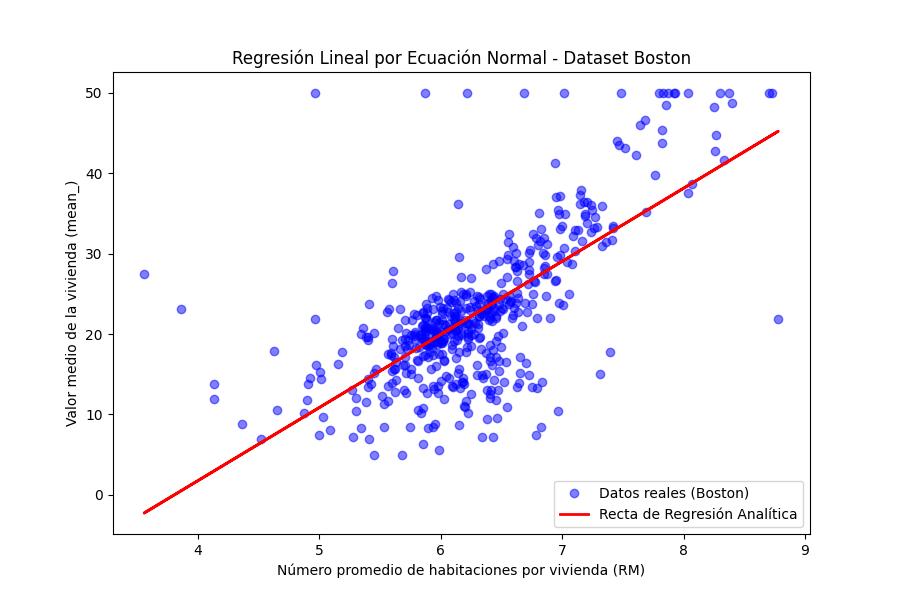

In [78]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Se define la URL de origen de los datos del dataset de Boston
data_url = "http://lib.stat.cmu.edu/datasets/boston"

# Se realiza la lectura del archivo CSV procesando espacios en blanco y omitiendo el encabezado descriptivo
raw_df = pd.read_csv(data_url, sep=r"\s+", skiprows=22, header=None)

# Se procesa la matriz de características debido al formato intercalado del archivo de origen
data = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])

# Se extrae la columna objetivo correspondiente al valor medio de las viviendas
target = raw_df.values[1::2, 2]

# Se construye el DataFrame final utilizando la columna objetivo y la característica 'rm' (índice 5 de data)
df = pd.DataFrame({"mean_": target, "rm": data[:, 5]})

# Se preparan las variables para el modelo: X (característica predictora) e y (variable objetivo)
X_train = df[["rm"]].values
y_train = df["mean_"].values

# Se crea una instancia de la clase que soluciona la ecuación normal
model = NormalEquationLinearRegression()

# Se ejecuta el ajuste del modelo con los datos extraídos para calcular los valores óptimos de theta
model.fit(X_train, y_train)

# Se imprimen los valores de los parámetros calculados (intercepto y pendiente)
print("Valores óptimos de Theta encontrados:")
print(f"Theta_0 (Intercepto): {model.theta[0][0]:.4f}")
print(f"Theta_1 (Pendiente para RM): {model.theta[1][0]:.4f}")

# Se generan predicciones basadas en los valores de entrenamiento para trazar la línea de regresión
predictions = model.predict(X_train)

# Se grafica el diagrama de dispersión de los datos reales junto con la recta analítica calculada
plt.figure(figsize=(9, 6))
plt.scatter(X_train, y_train, color="blue", alpha=0.5, label="Datos reales (Boston)")
plt.plot(X_train, predictions, color="red", linewidth=2, label="Recta de Regresión Analítica")
plt.xlabel("Número promedio de habitaciones por vivienda (RM)")
plt.ylabel("Valor medio de la vivienda (mean_)")
plt.title("Regresión Lineal por Ecuación Normal - Dataset Boston")
plt.legend()
plt.show()